# House Price Prediction using Linear Regression

## Overview
This project predicts house prices using Linear Regression. 
The model is trained on housing data and learns the relationship between features and price.

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##  Load Dataset

In [3]:
df=pd.read_csv("house_prices.csv")
df

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,187526,3 BHK Ready to Occupy Flat for sale in Bollywo...,This magnificent 3 BHK Flat is available for s...,63 Lac,3225.0,zirakpur,NaN,Ready to Move,2 out of 4,New Property,...,East,Garden/Park,Bollywood Esencia,3,3,1 Covered,Freehold,1953 sqft,NaN,NaN
187527,187527,3 BHK Ready to Occupy Flat for sale in Sushma ...,Have a look at this immaculate 3 BHK flat for ...,55 Lac,3274.0,zirakpur,NaN,Ready to Move,4 out of 6,Resale,...,North - East,"Garden/Park, Main Road",Sushma Urban Views,3,NaN,1 Covered,NaN,1680 sqft,NaN,NaN
187528,187528,3 BHK Ready to Occupy Flat for sale in Bollywo...,"Gazipur, Zirakpur has an appealing 3 BHK flat ...",76 Lac,4343.0,zirakpur,1250 sqft,Ready to Move,1 out of 3,Resale,...,East,"Garden/Park, Main Road",Bollywood Esencia,3,2,"1 Covered,",Freehold,NaN,NaN,NaN
187529,187529,2 BHK Ready to Occupy Flat for sale in Friends...,Up for immediate sale is a 2 BHK apartment in ...,30 Lac,4231.0,zirakpur,NaN,Ready to Move,2 out of 2,Resale,...,NaN,Main Road,Friends Enclave,2,NaN,NaN,NaN,709 sqft,NaN,NaN


## Data Preprocessing

In [4]:
print(df.shape)
df.info()
df.describe()

(187531, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  ob

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df=df.drop(columns=["Plot Area","Dimensions"]) #null columns
df=df.drop(columns=["Title","Description","Status"])#not needed
df=df.dropna(subset=["Price (in rupees)"])
df

,Index,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area
0,0,42 Lac,6000.0,thane,500 sqft,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN
1,1,98 Lac,13799.0,thane,473 sqft,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN
2,2,1.40 Cr,17500.0,thane,779 sqft,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN
4,4,1.60 Cr,18824.0,thane,635 sqft,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN
5,5,45 Lac,6618.0,thane,NaN,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",Virat Aangan,1,1,NaN,Co-operative Society,680 sqft
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,187526,63 Lac,3225.0,zirakpur,NaN,2 out of 4,New Property,Semi-Furnished,East,Garden/Park,Bollywood Esencia,3,3,1 Covered,Freehold,1953 sqft
187527,187527,55 Lac,3274.0,zirakpur,NaN,4 out of 6,Resale,Unfurnished,North - East,"Garden/Park, Main Road",Sushma Urban Views,3,NaN,1 Covered,NaN,1680 sqft
187528,187528,76 Lac,4343.0,zirakpur,1250 sqft,1 out of 3,Resale,Furnished,East,"Garden/Park, Main Road",Bollywood Esencia,3,2,"1 Covered,",Freehold,NaN
187529,187529,30 Lac,4231.0,zirakpur,NaN,2 out of 2,Resale,Semi-Furnished,NaN,Main Road,Friends Enclave,2,NaN,NaN,NaN,709 sqft


In [8]:
df["Price (in rupees)"].isnull().sum()

np.int64(0)

In [9]:
df["Carpet Area"] = df["Carpet Area"].str.extract(r'(\d+)') 
df["Carpet Area"] = pd.to_numeric(df["Carpet Area"], errors='coerce') 
df["Super Area"] = df["Super Area"].str.extract(r'(\d+)') 
df["Super Area"] = pd.to_numeric(df["Super Area"], errors='coerce') 
df["Bathroom"] = pd.to_numeric(df["Bathroom"], errors='coerce') 
df["Balcony"] = pd.to_numeric(df["Balcony"], errors='coerce')

In [10]:
df.isnull().sum()

Index                    0
Amount(in rupees)        0
Price (in rupees)        0
location                 0
Carpet Area          76235
Floor                 6843
Transaction              6
Furnishing            2060
facing               62052
overlooking          70646
Society              97433
Bathroom               782
Balcony              45077
Car Parking          90950
Ownership            58237
Super Area           93631
dtype: int64

In [11]:
df[["Carpet Area","Super Area"]].corr()

,Carpet Area,Super Area
Carpet Area,1.0,NaN
Super Area,NaN,1.0


In [12]:
missing=(df.isnull().sum()/len(df))*100
missing

Index                 0.000000
Amount(in rupees)     0.000000
Price (in rupees)     0.000000
location              0.000000
Carpet Area          44.879493
Floor                 4.028469
Transaction           0.003532
Furnishing            1.212721
facing               36.529971
overlooking          41.589253
Society              57.358742
Bathroom              0.460363
Balcony              26.536800
Car Parking          53.542204
Ownership            34.284083
Super Area           55.120507
dtype: float64

In [13]:
df.drop(columns=["Super Area","Society","Car Parking"])

,Index,Amount(in rupees),Price (in rupees),location,Carpet Area,Floor,Transaction,Furnishing,facing,overlooking,Bathroom,Balcony,Ownership
0,0,42 Lac,6000.0,thane,500.0,10 out of 11,Resale,Unfurnished,NaN,NaN,1.0,2.0,NaN
1,1,98 Lac,13799.0,thane,473.0,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,2.0,NaN,Freehold
2,2,1.40 Cr,17500.0,thane,779.0,10 out of 29,Resale,Unfurnished,East,Garden/Park,2.0,NaN,Freehold
4,4,1.60 Cr,18824.0,thane,635.0,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",2.0,NaN,Co-operative Society
5,5,45 Lac,6618.0,thane,NaN,2 out of 7,Resale,Unfurnished,East,"Garden/Park, Main Road",1.0,1.0,Co-operative Society
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187526,187526,63 Lac,3225.0,zirakpur,NaN,2 out of 4,New Property,Semi-Furnished,East,Garden/Park,3.0,3.0,Freehold
187527,187527,55 Lac,3274.0,zirakpur,NaN,4 out of 6,Resale,Unfurnished,North - East,"Garden/Park, Main Road",3.0,NaN,NaN
187528,187528,76 Lac,4343.0,zirakpur,1250.0,1 out of 3,Resale,Furnished,East,"Garden/Park, Main Road",3.0,2.0,Freehold
187529,187529,30 Lac,4231.0,zirakpur,NaN,2 out of 2,Resale,Semi-Furnished,NaN,Main Road,2.0,NaN,NaN


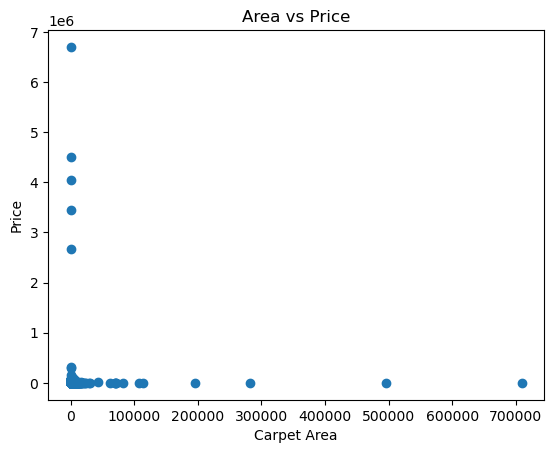

In [14]:
plt.scatter(df["Carpet Area"],df["Price (in rupees)"])
plt.xlabel("Carpet Area")
plt.ylabel("Price")
plt.title("Area vs Price")
plt.show()

In [15]:
df=df.fillna(df.median(numeric_only=True))
df = df.drop(columns=[
    'Index',
    'Amount(in rupees)',
    'location',
    'Floor',
    'Transaction',
    'Furnishing',
    'facing',
    'overlooking',
    'Car Parking',
    'Ownership',
    'Society'
])


In [16]:
Y=df["Price (in rupees)"].values.reshape(-1,1) #all col except price
X=df.drop(columns=["Price (in rupees)"]).values #converts automat to numpy

## Train-Test Split & Normalization

In [17]:
np.random.seed(42)
indices=np.random.permutation(len(X)) #to prevent bias
split = int(0.8 * len(X))      
train_idx = indices[:split] #80% data for training
test_idx = indices[split:]  #20% data for testing

X_train=X[train_idx]
X_test=X[test_idx]
Y_train=Y[train_idx]
Y_test=Y[test_idx]

mean=X_train.mean(axis=0) #axis=0-> go column wise
std=X_train.std(axis=0)
X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

In [18]:
X_train=np.column_stack((np.ones(X_train.shape[0]),X_train))
X_test=np.column_stack((np.ones(X_test.shape[0]),X_test))

## Model Building

In [19]:
def loss(X,Y,w):
    n=len(Y)
    error=X@w-Y
    return (1/n)*(error.T@error)[0][0]

def gradient(X,Y,w):
    n=len(Y)
    return (2/n)*X.T@(X@w-Y)

def gradient_descent(X,Y,lr=0.01,epoch=500):
    w=np.zeros((X.shape[1], 1))  
    loss_history=[]
    weight_history=[]

    for i in range(epoch):
        g=gradient(X,Y,w)
        w=w-lr*g
        loss_history.append(loss(X, Y, w))
        weight_history.append(w.copy())
    return w,loss_history,weight_history   

## Training Model

In [20]:
learning_rate=0.01
epoch=500

w_final, loss_history, weight_history = gradient_descent(
    X_train, Y_train, learning_rate, epoch
)

print("Final weights:")
print(w_final)

Final weights:
[[ 7.55777634e+03]
 [-8.36122263e-01]
 [ 1.72452753e+03]
 [ 4.84279465e+02]
 [-3.63952116e+02]]


## Loss Visualisation

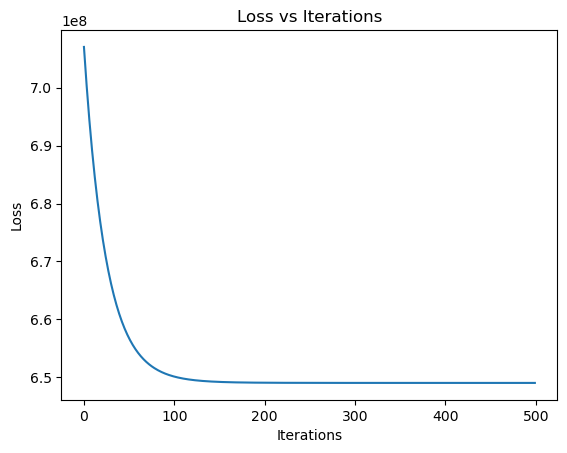

In [21]:
plt.plot(loss_history)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

In [22]:
test_loss = loss(X_test, Y_test, w_final)
print("Test Loss:", test_loss)

def r2_score(X, Y, w):
    predictions = X @ w
    ss_res = np.sum((Y - predictions)**2)
    ss_tot = np.sum((Y - Y.mean())**2)
    return 1 - (ss_res / ss_tot)

print("Train R2:", r2_score(X_train, Y_train, w_final))
print("Test R2:", r2_score(X_test, Y_test, w_final))

Test Loss: 1098819355.0283265
Train R2: 0.00511924261963248
Test R2: 0.002068674787148672


##  Conclusion
The Linear Regression model was successfully trained using Gradient Descent to predict house prices. The model shows good performance based on loss and R² score.